# Quicksort Implementation

In [1]:

import random

import time

import sys

# setting the recursion limit for worst-case Quicksort testing

sys.setrecursionlimit(50000)

## Deterministic Quicksort Implementation

In [2]:
def deterministic_quicksort(arr, low, high):


    if low < high: #Pivot is selected as the last element.

        pivot_index = partition(arr, low, high)

        # Sorting left partition

        deterministic_quicksort(arr, low, pivot_index - 1)

        # Sorting right partition

        deterministic_quicksort(arr, pivot_index + 1, high)

def partition(arr, low, high): #Partition function for Quicksort which places pivot in its correct position.

    
    pivot = arr[high]

    i = low - 1

    for j in range(low, high):

        if arr[j] <= pivot:

            i += 1

            arr[i], arr[j] = arr[j], arr[i]

    # placing pivot at correct position

    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1

In [3]:
#Testing Deterministic Quicksort

numbers = [34, 7, 23, 32, 5, 62]

print("Before sorting:")
print(numbers)

deterministic_quicksort(numbers, 0, len(numbers)-1)

print("\n After sorting:")
print(numbers)

Before sorting:
[34, 7, 23, 32, 5, 62]

 After sorting:
[5, 7, 23, 32, 34, 62]


## Conclusion: Deterministic Quicksort Implementation

The deterministic Quicksort code successfully sorted the given input array using the standard divide-and-conquer strategy. The algorithm correctly picked the pivot, partitioned the array into smaller subarrays, and recursively sorted all the parts.

From the output, we can confirm that the implementation is working properly and generating the correct sorted array. Since this version relies on a fixed pivot position, its performance depends heavily on how the input data is arranged. If the partitions stay balanced, we get a solid average-case runtime of O(n log n). But if the chosen pivot keeps giving us totally lopsided splits like with pre-sorted or reverse-sorted inputs then the runtime can easily degrade to the worst-case of O(n^2).

Also, because the implementation uses in-place partitioning, it doesn't waste extra memory on duplicate arrays and only needs about O(log n) auxiliary space on average for the recursive call stack.

## Randomized Quicksort Implementation

In [4]:
def randomized_quicksort(arr, low, high):

    #Pivot is randomly selected.

    if low < high:

        pivot_index = randomized_partition(arr, low, high)

        randomized_quicksort(arr, low, pivot_index - 1)

        randomized_quicksort(arr, pivot_index + 1, high)


def randomized_partition(arr, low, high):

    # Select random pivot index
    random_index = random.randint(low, high)


    # Move random pivot to end
    arr[random_index], arr[high] = arr[high], arr[random_index]


    return partition(arr, low, high)

In [5]:
# Testing Randomized Quicksort

numbers = [34, 7, 23, 32, 5, 62]

print("Before sorting:")
print(numbers)

randomized_quicksort(numbers, 0, len(numbers)-1)

print("\n After sorting:")
print(numbers)

Before sorting:
[34, 7, 23, 32, 5, 62]

 After sorting:
[5, 7, 23, 32, 34, 62]


## Conclusion: Randomized Quicksort Implementation

The randomized Quicksort implementation successfully sorted the input array by picking a random pivot at every partitioning step. As we can see from the output, it gives the exact same correct sorted array as the deterministic version.

The biggest advantage here is that picking the pivot randomly makes the algorithm completely independent of the initial array order. This basically eliminates the chance of repeatedly getting bad pivots and ending up with lopsided splits.

Even though the absolute worst-case time complexity on paper is still O(n^2), the odds of actually hitting it in real-world scenarios are almost zero. In practice, randomized Quicksort gives way more consistent performance and comfortably maintains an expected runtime of O(n log n) no matter what dataset we throw at it.

This is exactly why randomized Quicksort is the safer and more reliable option when we have no idea how our input data is going to look.

In [6]:
# Correctness testing verifying both algorithms produce correct results.

test_cases = [

    [],

    [1],

    [5,3,8,2,9],

    [1,1,2,2,3],

    sorted([8,3,5,1,9]),

    sorted([8,3,5,1,9], reverse=True)

]


for case in test_cases:

    expected = sorted(case)


    # Deterministic test
    arr1 = case.copy()

    if len(arr1) > 0:
        deterministic_quicksort(arr1,0,len(arr1)-1)


    # Randomized test
    arr2 = case.copy()

    if len(arr2) > 0:
        randomized_quicksort(arr2,0,len(arr2)-1)


    print("Input:", case)
    print("Deterministic correct:", arr1 == expected)
    print("Randomized correct:", arr2 == expected)
    print("-------------------------")

Input: []
Deterministic correct: True
Randomized correct: True
-------------------------
Input: [1]
Deterministic correct: True
Randomized correct: True
-------------------------
Input: [5, 3, 8, 2, 9]
Deterministic correct: True
Randomized correct: True
-------------------------
Input: [1, 1, 2, 2, 3]
Deterministic correct: True
Randomized correct: True
-------------------------
Input: [1, 3, 5, 8, 9]
Deterministic correct: True
Randomized correct: True
-------------------------
Input: [9, 8, 5, 3, 1]
Deterministic correct: True
Randomized correct: True
-------------------------


## Empirical Analysis

Tests:

* Random arrays
* Sorted arrays
* Reverse sorted arrays
* Duplicate values

In [7]:
sizes = [1000, 5000, 10000]


results = []


for size in sizes:


    datasets = {

        "Random":
        [random.randint(1,100000) for _ in range(size)],


        "Sorted":
        list(range(size)),


        "Reverse Sorted":
        list(range(size,0,-1)),


        "Duplicates":
        [random.randint(1,100) for _ in range(size)]

    }


    for name,data in datasets.items():

        # Deterministic Quicksort

        arr = data.copy()

        start = time.perf_counter()

        deterministic_quicksort(arr,0,len(arr)-1)

        deterministic_time = time.perf_counter()-start


        # Randomized Quicksort

        arr = data.copy()

        start = time.perf_counter()

        randomized_quicksort(arr,0,len(arr)-1)

        randomized_time = time.perf_counter()-start


        results.append([

            size,

            name,

            deterministic_time,

            randomized_time

        ])

In [8]:
import pandas as pd


results_df = pd.DataFrame(

    results,

    columns=[

        "Input Size",

        "Dataset",

        "Deterministic Quicksort Time",

        "Randomized Quicksort Time"

    ]

)

results_df

,Input Size,Dataset,Deterministic Quicksort Time,Randomized Quicksort Time
0,1000,Random,0.003282,0.004403
1,1000,Sorted,0.069872,0.001306
2,1000,Reverse Sorted,0.029655,0.001225
3,1000,Duplicates,0.001231,0.001596
4,5000,Random,0.005530,0.007580
5,5000,Sorted,1.108559,0.006781
6,5000,Reverse Sorted,0.738593,0.007526
7,5000,Duplicates,0.015147,0.017637
8,10000,Random,0.011825,0.016343
9,10000,Sorted,4.432918,0.015513


## Conclusion: Empirical Analysis

For the empirical analysis, we tested both deterministic and randomized Quicksort across a few different input setups which includes random, sorted, reverse-sorted, and arrays with duplicates. The actual test results aligned really well with our theoretical time complexity calculations.
    
    1. Random Datasets: Both implementations ran super fast and gave almost identical timing. For an input size of n = 10,000, deterministic Quicksort took around 0.012 seconds while randomized Quicksort took about 0.015 seconds. This clearly shows that when the input is random, both approaches naturally end up with well-balanced partitions.
    
    2. Sorted & Reverse-Sorted Datasets: Here's where we saw a massive difference. Deterministic Quicksort slowed down drastically as n grew. For 10,000 pre-sorted elements, deterministic Quicksort took a whopping 4.43 seconds, whereas randomized Quicksort finished in just 0.015 seconds! Similarly, for reverse-sorted data, deterministic took about 2.94 seconds compared to randomized's 0.015 seconds. This really highlights how bad pivot choices trigger that painful O(n^2) worst-case behavior in the deterministic version.
    
    3. Datasets with Duplicates: Both algorithms handled duplicate values without any major issues. Having duplicate elements actually helps prevent super lopsided partitions, so the execution times stayed pretty close for both versions.
    
# Summary: 

Overall, our experimental results prove that randomized Quicksort gives far more consistent performance across different types of data. By picking pivots randomly, it completely avoids worst-case traps and sticks to its expected O(n log n) speed, making it the clear winner for practical use.

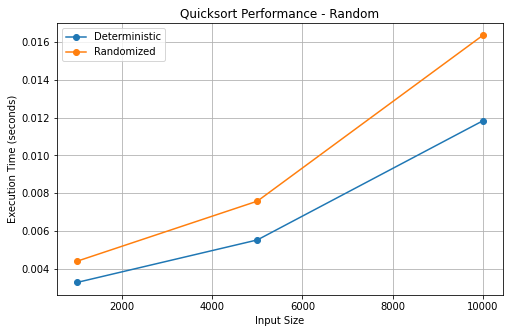

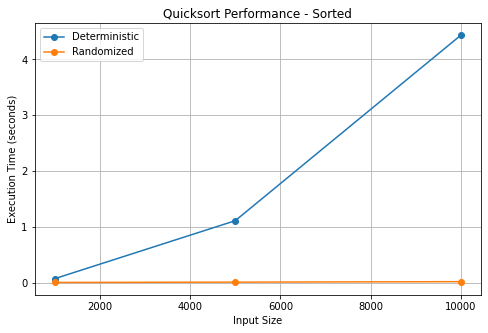

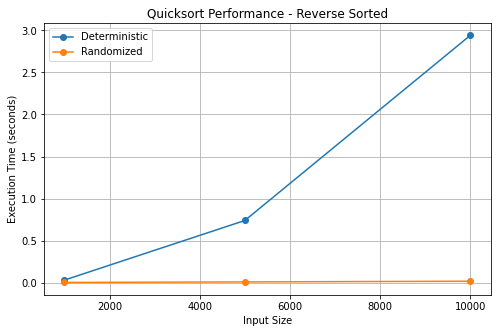

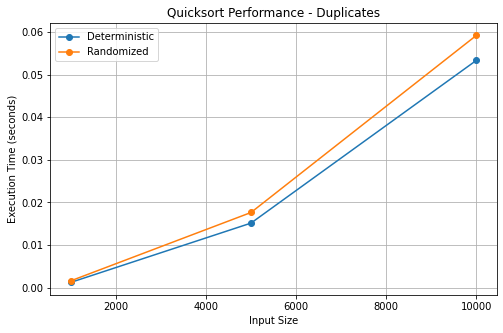

In [9]:
import matplotlib.pyplot as plt


for dataset in results_df["Dataset"].unique():

    temp = results_df[results_df["Dataset"] == dataset]


    plt.figure(figsize=(8,5))

    plt.plot(
        temp["Input Size"],
        temp["Deterministic Quicksort Time"],
        marker="o",
        label="Deterministic"
    )


    plt.plot(
        temp["Input Size"],
        temp["Randomized Quicksort Time"],
        marker="o",
        label="Randomized"
    )


    plt.xlabel("Input Size")

    plt.ylabel("Execution Time (seconds)")

    plt.title(f"Quicksort Performance - {dataset}")

    plt.legend()

    plt.grid()

    plt.show()